<a href="https://colab.research.google.com/github/Unis237/Cameroon-pidgin-news-classification/blob/main/cmr-pidgin-news-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import xgboost as xgb
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Data & Create Splits

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/nlp_data/train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/nlp_data/test.csv')

train_final, dev_df = train_test_split(
    train_df, test_size=0.10, random_state=42,
    stratify=train_df['label']
)

train_final.to_csv('train_split.csv', index=False)
dev_df.to_csv('dev_split.csv', index=False)

print(f"Train: {len(train_final)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
print("\nLabel distribution:\n", train_final['label'].value_counts())

Train: 900 | Dev: 100 | Test: 150

Label distribution:
 label
politics         163
business         151
sports           149
health           149
technology       149
entertainment    139
Name: count, dtype: int64


Classical ML Baselines

In [ ]:
X_train = train_final['headline']
y_train = train_final['label']
X_test  = test_df['headline']
y_test  = test_df['label']

# Vectorize
vectorizer  = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# Encode labels
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Naive Bayes
nb       = MultinomialNB()
nb.fit(X_train_vec, y_train_enc)
nb_preds = nb.predict(X_test_vec)
nb_f1    = f1_score(y_test_enc, nb_preds, average='weighted') * 100
print(f"NaiveBayes : {nb_f1:.2f}%")
print(classification_report(y_test_enc, nb_preds, target_names=le.classes_))

# MLP
mlp       = MLPClassifier(hidden_layer_sizes=(256,), max_iter=50, random_state=42)
mlp.fit(X_train_vec, y_train_enc)
mlp_preds = mlp.predict(X_test_vec)
mlp_f1    = f1_score(y_test_enc, mlp_preds, average='weighted') * 100
print(f"MLP        : {mlp_f1:.2f}%")
print(classification_report(y_test_enc, mlp_preds, target_names=le.classes_))

# XGBoost
xgb_clf   = xgb.XGBClassifier(n_estimators=100, max_depth=6,
                                random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train_vec, y_train_enc)
xgb_preds = xgb_clf.predict(X_test_vec)
xgb_f1    = f1_score(y_test_enc, xgb_preds, average='weighted') * 100
print(f"XGBoost    : {xgb_f1:.2f}%")
print(classification_report(y_test_enc, xgb_preds, target_names=le.classes_))

NaiveBayes : 83.34%
               precision    recall  f1-score   support

     business       0.77      0.71      0.74        28
entertainment       0.89      0.86      0.87        28
       health       0.88      0.88      0.88        25
     politics       0.85      0.88      0.86        25
       sports       0.88      0.88      0.88        26
   technology       0.70      0.78      0.74        18

     accuracy                           0.83       150
    macro avg       0.83      0.83      0.83       150
 weighted avg       0.83      0.83      0.83       150



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP        : 87.33%
               precision    recall  f1-score   support

     business       0.79      0.82      0.81        28
entertainment       0.90      0.96      0.93        28
       health       0.88      0.88      0.88        25
     politics       1.00      0.88      0.94        25
       sports       0.89      0.92      0.91        26
   technology       0.76      0.72      0.74        18

     accuracy                           0.87       150
    macro avg       0.87      0.87      0.87       150
 weighted avg       0.88      0.87      0.87       150

XGBoost    : 79.22%
               precision    recall  f1-score   support

     business       0.69      0.79      0.73        28
entertainment       0.95      0.68      0.79        28
       health       0.75      0.84      0.79        25
     politics       0.80      0.64      0.71        25
       sports       0.93      1.00      0.96        26
   technology       0.68      0.83      0.75        18

     accuracy       

 Fine-tuning a Multilingual Language Model

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
import torch
import numpy as np
from sklearn.metrics import f1_score

# --- Config ---
MODEL_NAME = "Davlan/afro-xlmr-base"   # Africa-centric model
NUM_LABELS = 6
LABEL_LIST = ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
label2id = {l: i for i, l in enumerate(LABEL_LIST)}
id2label = {i: l for l, i in label2id.items()}

# --- Load Data ---
train_df = pd.read_csv('train_split.csv')
dev_df   = pd.read_csv('dev_split.csv')

# Map labels to integers
for df in [train_df, dev_df, test_df]:
    df['label_id'] = df['label'].map(label2id)

# Convert to HuggingFace Dataset format
train_ds = Dataset.from_pandas(train_df[['headline', 'label_id']])
dev_ds   = Dataset.from_pandas(dev_df[['headline', 'label_id']])
test_ds  = Dataset.from_pandas(test_df[['headline', 'label_id']])

# --- Tokenize ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['headline'], truncation=True, max_length=128, padding='max_length')

train_ds = train_ds.map(tokenize, batched=True)
dev_ds   = dev_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Rename label column for Trainer
train_ds = train_ds.rename_column('label_id', 'labels')
dev_ds   = dev_ds.rename_column('label_id', 'labels')
test_ds  = test_ds.rename_column('label_id', 'labels')

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

# --- Model ---
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    id2label=id2label, label2id=label2id
)

# --- Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average='weighted')
    return {'weighted_f1': f1}

# --- Training Args ---
# Why these settings? Matching the paper: 20 epochs, batch_size=32, lr=1e-5 to 5e-5
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='weighted_f1',
    logging_steps=10,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

# --- Evaluate on Test ---
results = trainer.evaluate(test_ds)
print("Test results:", results)


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Test results: {'eval_loss': 0.21049991250038147, 'eval_weighted_f1': 0.939279873033743, 'eval_runtime': 1.0043, 'eval_samples_per_second': 149.359, 'eval_steps_per_second': 2.987, 'epoch': 10.0}


In [24]:
from sklearn.metrics import classification_report
import numpy as np

preds_output = trainer.predict(test_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
print(classification_report(list(test_ds['labels']), preds, target_names=LABEL_LIST))

               precision    recall  f1-score   support

     business       0.93      0.89      0.91        28
entertainment       0.96      0.96      0.96        28
       health       0.96      1.00      0.98        25
     politics       0.91      0.84      0.88        25
       sports       0.96      0.96      0.96        26
   technology       0.90      1.00      0.95        18

     accuracy                           0.94       150
    macro avg       0.94      0.94      0.94       150
 weighted avg       0.94      0.94      0.94       150



In [ ]:
trainer.save_model('/content/drive/MyDrive/nlp_data/afro_xlmr2')
print("Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Load Saved LM & Evaluate

In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch

LABEL_LIST = ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
label2id   = {l: i for i, l in enumerate(LABEL_LIST)}
id2label   = {i: l for l, i in label2id.items()}
MODEL_PATH = '/content/drive/MyDrive/nlp_data/afro_xlmr2'

# Load saved model
tokenizer = AutoTokenizer.from_pretrained('Davlan/afro-xlmr-base')
model     = AutoModelForSequenceClassification.from_pretrained(
                MODEL_PATH, num_labels=6,
                id2label=id2label, label2id=label2id)

# Prepare test set
test_df['label_id'] = test_df['label'].map(label2id)
test_ds = Dataset.from_pandas(test_df[['headline', 'label_id']])

def tokenize(batch):
    return tokenizer(batch['headline'], truncation=True,
                     max_length=128, padding='max_length')

test_ds = test_ds.map(tokenize, batched=True)
test_ds = test_ds.rename_column('label_id', 'labels')
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

# Trainer for evaluation only
training_args = TrainingArguments(
    output_dir='./eval_results',
    per_device_eval_batch_size=64,
    seed=42,
)
trainer = Trainer(model=model, args=training_args)

# Get predictions
preds_output = trainer.predict(test_ds)
preds        = np.argmax(preds_output.predictions, axis=-1)
lm_f1        = f1_score(list(test_ds['labels']), preds, average='weighted') * 100

print(f"AfroXLMR-base : {lm_f1:.2f}%")
print(classification_report(list(test_ds['labels']), preds, target_names=LABEL_LIST))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

AfroXLMR-base : 93.93%
               precision    recall  f1-score   support

     business       0.93      0.89      0.91        28
entertainment       0.96      0.96      0.96        28
       health       0.96      1.00      0.98        25
     politics       0.91      0.84      0.88        25
       sports       0.96      0.96      0.96        26
   technology       0.90      1.00      0.95        18

     accuracy                           0.94       150
    macro avg       0.94      0.94      0.94       150
 weighted avg       0.94      0.94      0.94       150



In [ ]:
All Visualizations

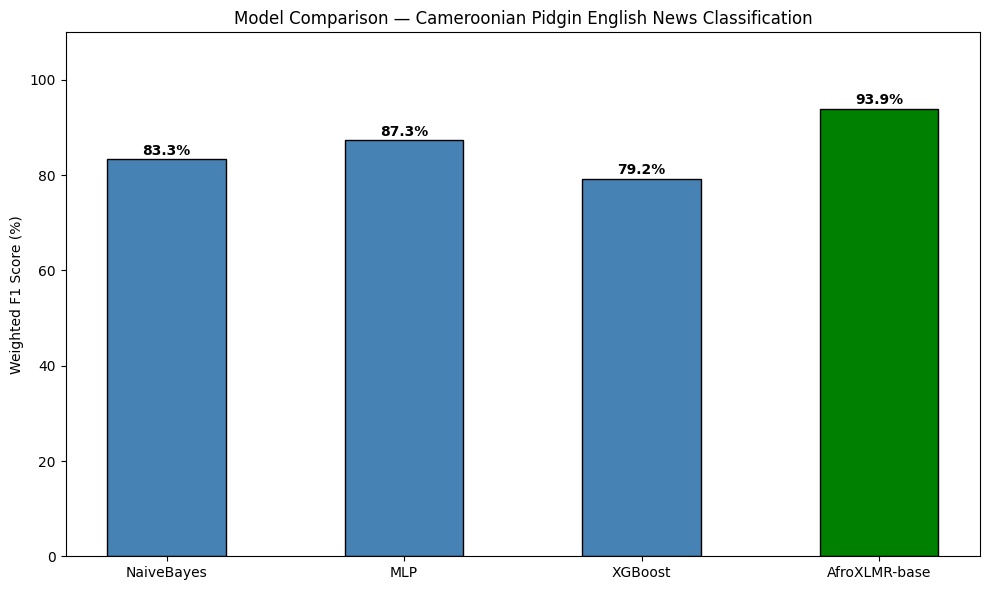

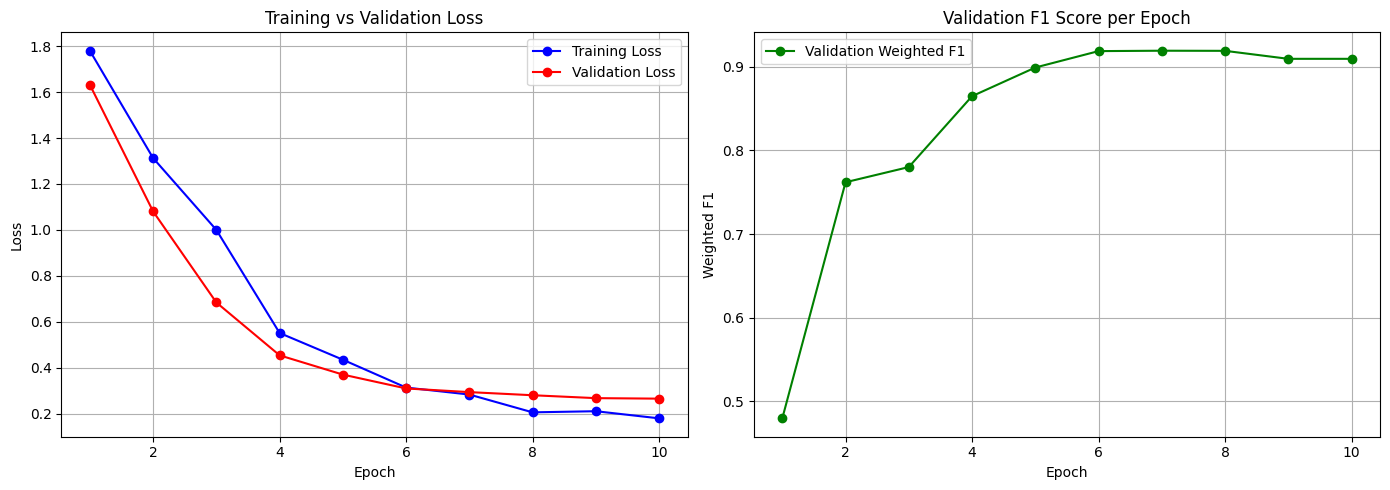

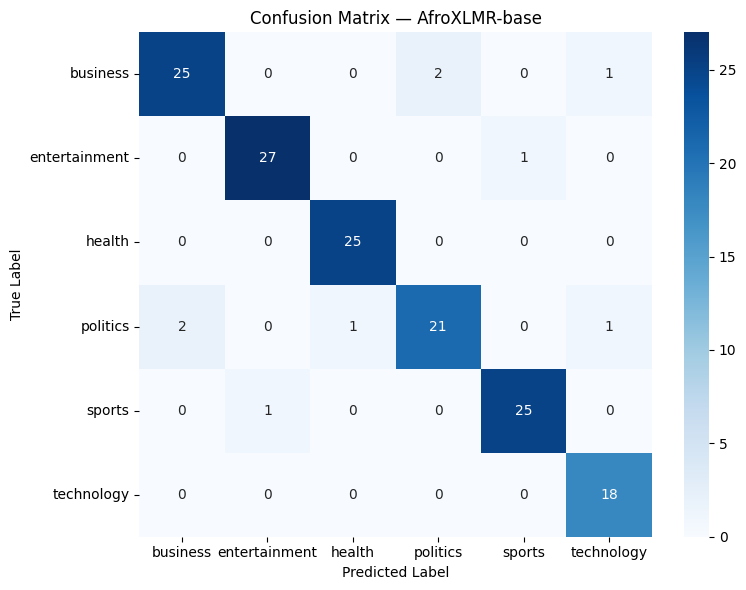

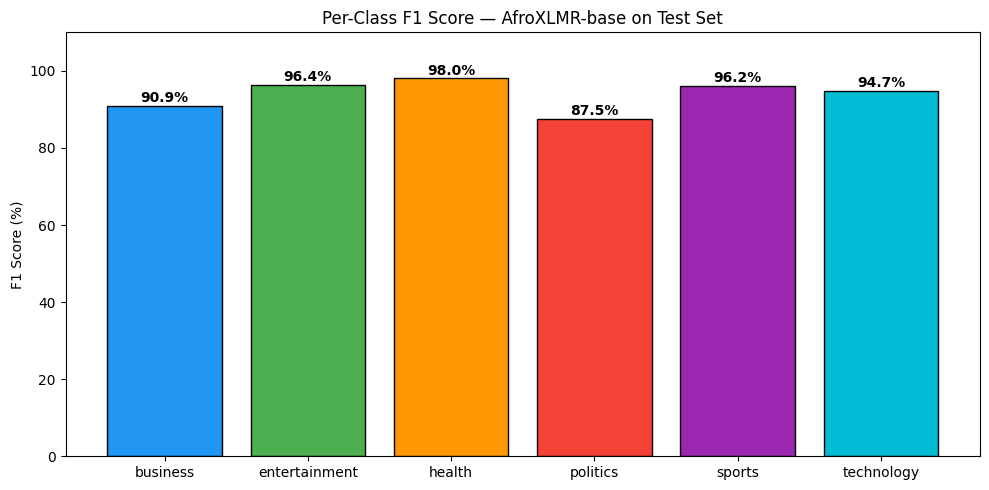


✅ All figures saved to Google Drive!


In [31]:
# ── 1. Model Comparison ──────────────────────────────────────────
models    = ['NaiveBayes', 'MLP', 'XGBoost', 'AfroXLMR-base']
f1_scores = [nb_f1, mlp_f1, xgb_f1, lm_f1]
colors    = ['steelblue', 'steelblue', 'steelblue', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color=colors, edgecolor='black', width=0.5)
plt.ylim(0, 110)
plt.ylabel('Weighted F1 Score (%)')
plt.title('Model Comparison — Cameroonian Pidgin English News Classification')
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_data/model_comparison.png', dpi=150)
plt.show()

# ── 2. Training Curves ───────────────────────────────────────────
epochs     = list(range(1, 11))
train_loss = [1.780399, 1.312756, 0.999799, 0.550817, 0.434435,
              0.313146, 0.282695, 0.205177, 0.210090, 0.179051]
val_loss   = [1.631966, 1.080371, 0.683704, 0.453503, 0.369613,
              0.309249, 0.293282, 0.279679, 0.267055, 0.264834]
val_f1     = [0.479768, 0.761905, 0.780051, 0.864764, 0.899006,
              0.918616, 0.919101, 0.918955, 0.909413, 0.909413]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, train_loss, 'b-o', label='Training Loss')
axes[0].plot(epochs, val_loss,   'r-o', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, val_f1, 'g-o', label='Validation Weighted F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].set_title('Validation F1 Score per Epoch')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_data/training_curves.png', dpi=150)
plt.show()

# ── 3. Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(list(test_ds['labels']), preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST)
plt.title('Confusion Matrix — AfroXLMR-base')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_data/confusion_matrix.png', dpi=150)
plt.show()

# ── 4. Per-Class F1 ─────────────────────────────────────────────
report       = classification_report(list(test_ds['labels']), preds,
                                     target_names=LABEL_LIST, output_dict=True)
per_class_f1 = [report[l]['f1-score'] * 100 for l in LABEL_LIST]
colors_pc    = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4']

plt.figure(figsize=(10, 5))
bars = plt.bar(LABEL_LIST, per_class_f1, color=colors_pc, edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('F1 Score (%)')
plt.title('Per-Class F1 Score — AfroXLMR-base on Test Set')
for bar, score in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_data/per_class_f1.png', dpi=150)
plt.show()

print("\n✅ All figures saved to Google Drive!")

Test examples

In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

LABEL_LIST = ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

# Get predictions
preds_output = trainer.predict(test_ds)
preds        = np.argmax(preds_output.predictions, axis=-1)
true_labels  = [LABEL_LIST[i] for i in list(test_ds['labels'])]
pred_labels  = [LABEL_LIST[i] for i in preds]

# Create results dataframe
results_df = pd.DataFrame({
    'ID'         : range(1, len(test_df) + 1),
    'Headline'   : test_df['headline'].values,
    'True Label' : true_labels,
    'Predicted'  : pred_labels,
})
results_df['Correct'] = results_df['True Label'] == results_df['Predicted']

# Overall statistics
total   = len(results_df)
correct = results_df['Correct'].sum()
wrong   = total - correct

print("="*60)
print("OVERALL STATISTICS")
print("="*60)
print(f"Total test examples : {total}")
print(f"Correct predictions : {correct}")
print(f"Wrong predictions   : {wrong}")
print(f"Accuracy            : {correct/total*100:.2f}%")

print("\n" + "="*60)
print("PER CLASS STATISTICS")
print("="*60)
print(classification_report(true_labels, pred_labels,
                             target_names=LABEL_LIST, digits=4))

print("="*60)
print("CORRECT PREDICTIONS PER CLASS")
print("="*60)
for label in LABEL_LIST:
    subset  = results_df[results_df['True Label'] == label]
    correct_count = results_df[(results_df['True Label'] == label) &
                               (results_df['Correct'] == True)]
    print(f"{label:<15} : {len(correct_count)}/{len(subset)} correct")

print("\n" + "="*60)
print("10 SAMPLE TEST PREDICTIONS")
print("="*60)
sample = results_df[['ID', 'Headline', 'True Label', 'Predicted']].head(10)
print(sample.to_string(index=False))

print("\n" + "="*60)
print("WRONG PREDICTIONS")
print("="*60)
wrong_df = results_df[results_df['Correct'] == False]
print(f"Total wrong: {len(wrong_df)}\n")
print(wrong_df[['ID', 'Headline', 'True Label', 'Predicted']].to_string(index=False))

# Save
results_df.to_csv('/content/drive/MyDrive/nlp_data/test_predictions.csv', index=False)
print("\nAll predictions saved to Drive!")

OVERALL STATISTICS
Total test examples : 150
Correct predictions : 141
Wrong predictions   : 9
Accuracy            : 94.00%

PER CLASS STATISTICS
               precision    recall  f1-score   support

     business     0.9259    0.8929    0.9091        28
entertainment     0.9643    0.9643    0.9643        28
       health     0.9615    1.0000    0.9804        25
     politics     0.9130    0.8400    0.8750        25
       sports     0.9615    0.9615    0.9615        26
   technology     0.9000    1.0000    0.9474        18

     accuracy                         0.9400       150
    macro avg     0.9377    0.9431    0.9396       150
 weighted avg     0.9399    0.9400    0.9393       150

CORRECT PREDICTIONS PER CLASS
business        : 25/28 correct
entertainment   : 27/28 correct
health          : 25/25 correct
politics        : 21/25 correct
sports          : 25/26 correct
technology      : 18/18 correct

10 SAMPLE TEST PREDICTIONS
 ID                                                